# Day 4 — Activations, Gradients, BatchNorm (makemore Part 3, 1h55m)
Lecture names used (n_embd, n_hidden, block_size, vocab_size). Init fixes + BatchNorm + Linear/BatchNorm1d/Tanh classes = my exercises. Starting network is deliberately pre-fix.

In [164]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [165]:
# BOILERPLATE: data + maps + split
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(word_list):
    X, Y = [], []
    for w in word_list:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [166]:
# starting network — NAIVE init (the video's fixes are my exercise)
n_embd = 10
n_hidden = 200

gain = 5/3 # due to using tanh, https://docs.pytorch.org/docs/2.13/nn.init.html
kaiming_init_scale = gain/((n_embd * block_size)**0.5)

bngain = torch.ones((1, n_hidden)) # γ, https://arxiv.org/pdf/1502.03167
bnbias = torch.zeros((1, n_hidden)) # β, https://arxiv.org/pdf/1502.03167

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * kaiming_init_scale # before * 0.1 now, kaiming_init_scale
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2, bnbias, bngain]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [167]:
# BOILERPLATE: optimization loop (use small max_steps during the surgery phase)
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1

    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

    hpreact = (hpreact - bnmean)/(bnstd)
    hpreact = bngain * (hpreact) + bnbias

    with torch.no_grad():
        bnmean_running = bnmean_running * 0.999 + bnmean * 0.001
        bnstd_running = bnstd_running * 0.999 + bnstd * 0.001

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


In [168]:
hpreact.shape

torch.Size([32, 200])

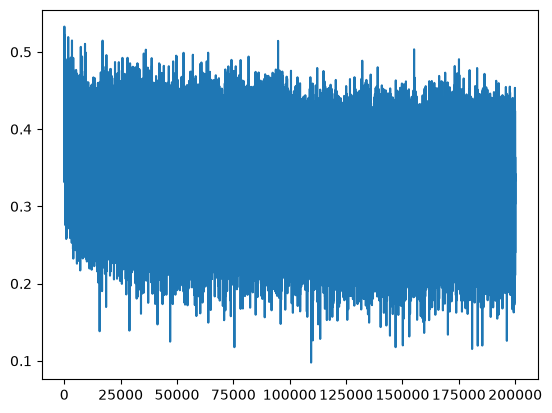

In [169]:
plt.plot(lossi)

In [170]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1
    hpreact = bngain * ((hpreact - bnmean_running)/bnstd_running) + bnbias
    h = hpreact.tanh()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.0674145221710205
dev 2.1056840419769287


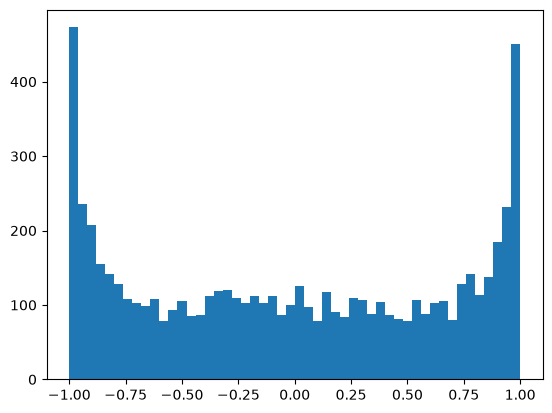

In [171]:
# BOILERPLATE (segment viz, from the lecture): distribution of h — where do activations live?
plt.hist(h.view(-1).tolist(), 50);

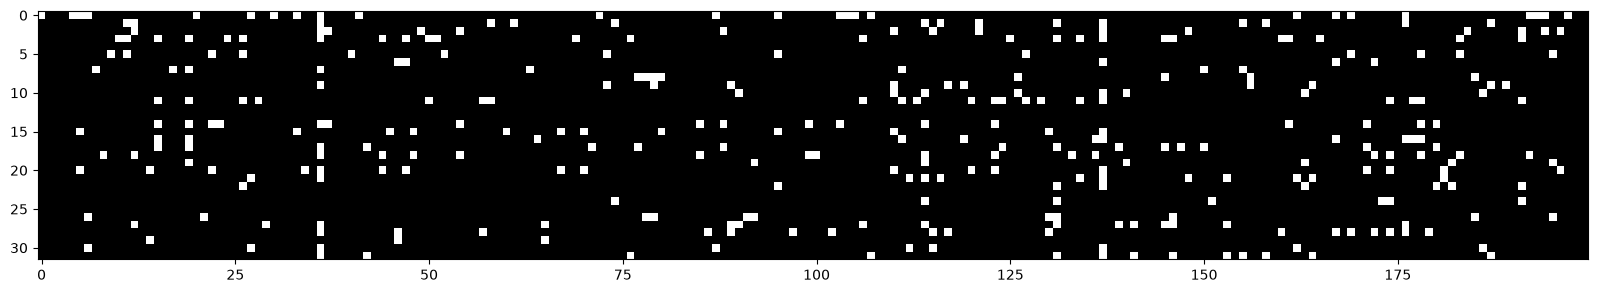

In [172]:
# BOILERPLATE (segment viz, from the lecture): saturation map — white = |h| > 0.99 (dead-ish)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [173]:
a = torch.zeros(27).float()
y = torch.tensor(1)
loss = F.cross_entropy(a, y)
loss

tensor(3.2958)

## observations — naive init, 200k run

- first loss 27.88 (same as karpathy), should be ~3.29. confidently wrong at init, same as my 21.9 thing before
- loss curve = hockey stick, early steps wasted just fixing the init
- still ended at train 2.1268 / dev 2.1698 tho. bad init didnt kill it, just wasted time (shallow net, deep would die)
- h histogram = two towers at ±1, saturated
- saturation map has a lot of white, those units have grad ~0
- derived the ideal init loss with a toy: cross_entropy(zeros(27), y) = -log(1/27) = **3.2958**. so logits should start ~0 -> OUTPUT layer (w2, b2) near 0. hidden layers dont get this, they need proper scale or signal dies

## observations — logits fix (w2 * 0.01, b2 = 0)

- step 0 loss: **3.3221**, basically the ideal 3.2958. no more hockey stick
- w2 was most of the issue (overconfidence). b2=0 didnt contribute much for this small nn but may come in handy later
- final: train 2.0696 / dev **2.1311** — better than naive's, the un-wasted early steps actually helped. also beats my part2 best (2.1678) lol
- W1 still naive -> tanh still saturated, thats next

## observations — tanh fix (w1 * 0.1, hand tuned)

- shrunk w1 by eye watching the histogram, towers at ±1 melted. kaiming formula says (5/3)/sqrt(30) ≈ 0.30, my 0.1 is smaller but works — exact number is forgiving here
- step 0: 3.3197, still ideal-ish
- final: train 2.0453 / dev **2.1037** — new best again. 3 fixes, 3 improvements: 2.1698 -> 2.1311 -> 2.1037
- clean rerun with b1 * 0.1 (bias was std 1, louder than the w1*0.1 signal at ~0.55 — scaled it down): step 0 3.3084, train 2.0613 / dev 2.1134. slightly worse than the 2.1037 run = run to run noise, ±0.01 doesnt mean anything here

## observations — kaiming init (no more hardcoding)

- from the pytorch docs: tanh gain = 5/3. fan_in for w1 = 30 = n_embd * block_size (3 chars x 10 dims flattened, = embcat's width)
- kaiming_init_scale = (5/3)/sqrt(30) ≈ 0.304, vs my hand tuned 0.1
- b1 * 0.01 now too
- step 0: 3.3179. final: train 2.0377 / dev **2.1070** — same as hand tuned (2.1134) within noise. the formula's win isnt a better number, its not needing the histogram eyeballing, works at any depth

## observations — batchnorm (by hand)

- implemented the paper's algorithm 1: batch mean/std over dim 0 keepdim, normalize, then bngain (γ) * x̂ + bnbias (β). gain=ones, bias=zeros so it starts as a pure standardizer
- BUG 1: divided by bnstd**2 = dividing by variance not std (symbol collision, paper says σ² but my var was already std). caught it with the contract check: post-normalize std(0) should be all 1s, wasnt. sneaky part: it still trained fine cause bngain just learned to absorb the wrong scale. accidentally-working again
- BUG 2 (hit it before watching the fix): trained w/ BN then split_loss showed train 2.98/dev 3.01 = garbage. eval forward had no BN + deeper problem: batch stats dont exist at eval (whats the std of 1 sample?). thats what the running stats are for
- running stats: bnmean_running (init zeros), bnstd_running (init ones), updated in no_grad with 0.999/0.001 momentum. NOT in parameters — buffers, not trained. i had the inits swapped at first (mean=ones/std=zeros), works after 200k anyway cause 0.999^200k kills the init. fixed for principle
- killed b1: mean subtraction cancels it, bnbias is its replacement. 12297 -> 12097 params
- final full run: **train 2.0666 / dev 2.1052** — same as kaiming-only (2.1070). BN didnt buy loss on this shallow well-init'd net, it buys insurance: could delete all the init care and still train, and it matters at depth. matching-not-beating is the expected result here

## observations — batchnorm

- implemented the paper's algorithm 1: batch mean/std over dim 0 (per neuron stats, keepdim), normalize, then bngain * x + bnbias. gain/bias are trainable (in parameters), start at ones/zeros = identity
- BUG 1: divided by bnstd**2 = variance not std. contract check (normalized std should be ~1) caught it. interesting: training looked fine anyway because bngain just learned to absorb the wrong scale. learnable rescaling hides bugs
- hit the eval problem MYSELF: split_loss scored 2.98/3.01 garbage after healthy training — its forward had no BN, and even with BN, what mean/std do you use? batch of 1 in the sampler has no std. thats why running stats exist
- running stats: bnmean_running/bnstd_running buffers (NOT in parameters, no grads, updated in no_grad with 0.999/0.001 momentum). BUG 2: initialized them swapped (mean=ones, std=zeros) — long run hides it since 0.999^200k ~ 0
- killed b1: mean subtraction cancels it, was dead weight. 12097 params now
- final with BN: train 2.0666 / dev **2.1052** — same as kaiming-only (2.1070) within noise. BN doesnt buy loss on a shallow well-inited net, it buys insurance: could delete all the init care and still train, and it holds distributions at depth where init cant